In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

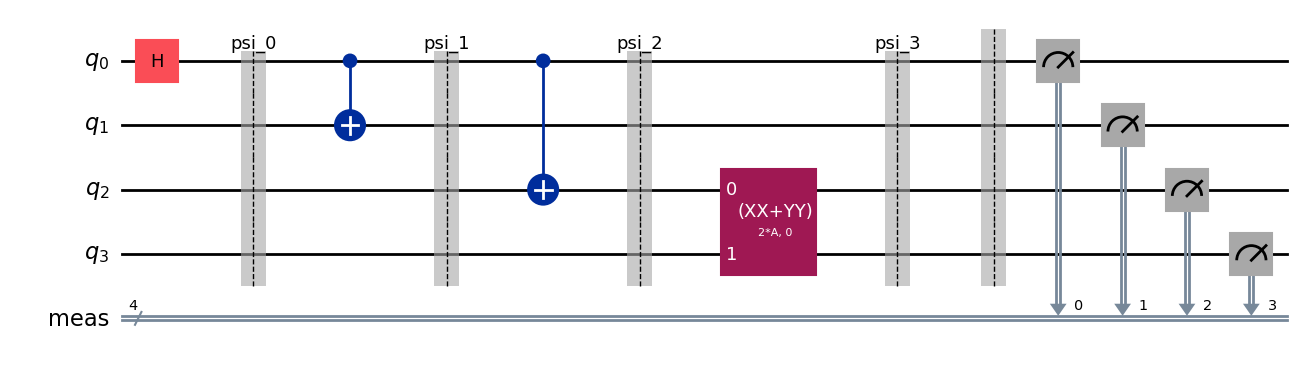

In [2]:
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import XXPlusYYGate
from qiskit.transpiler.passes import RemoveBarriers

from solver.circuits import XXPlusYYRZAnsatz1


qc = QuantumCircuit(4)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
a = Parameter('A')
qc.append(XXPlusYYGate(2 * a, 0),[2,3])
# qc = RemoveBarriers()(XXPlusYYRZAnsatz1(4,2).full_ansatz)

dag = circuit_to_dag(qc)
new_dag = dag.copy_empty_like()

for index, layer in enumerate(dag.layers()):
    circ = dag_to_circuit(layer['graph'])
    circ.save_statevector('psi_' + str(index))
    new_dag.compose(circuit_to_dag(circ))

qc = dag_to_circuit(new_dag)
qc.measure_all()
qc.draw(output='mpl')

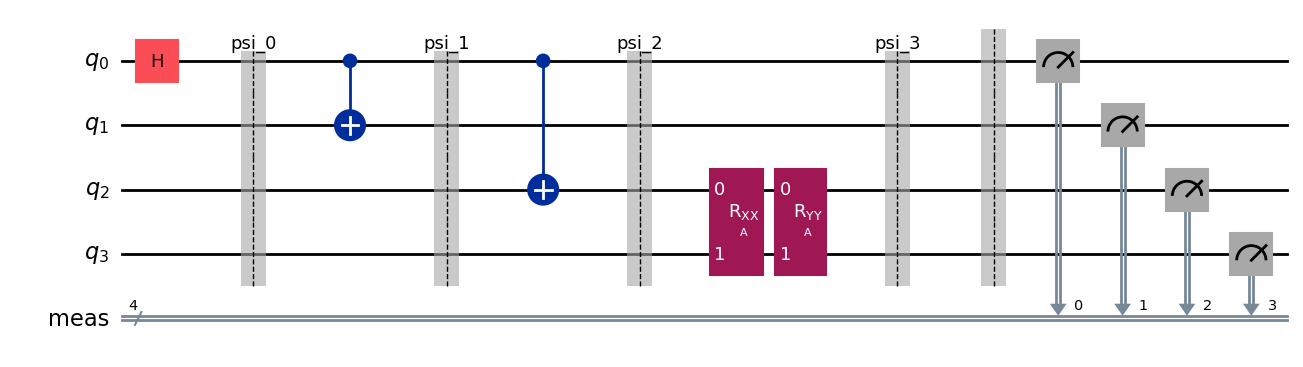

In [3]:
simulator_options = {
    "method": "statevector",
}
backend = AerSimulator(**simulator_options)

pm = generate_preset_pass_manager(backend=backend)

estimator = Estimator(mode=backend)
sampler = Sampler(mode=backend)
circuit = pm.run(qc)
circuit.draw(output='mpl')

In [4]:
result = backend.run(circuit, shots=1, parameter_binds=[{a: [2,1]}]).result()
result

Result(backend_name='aer_simulator_statevector', backend_version='0.17.1', job_id='8d7b3302-5c66-4caa-9bbc-aca3cb64ed82', success=True, results=[ExperimentResult(shots=1, success=True, meas_level=2, data=ExperimentResultData(counts={'0x0': 1}, psi_3=Statevector([ 0.70710678+0.00000000e+00j,  0.        +0.00000000e+00j,
              0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
              0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
              0.        +0.00000000e+00j, -0.29426025+0.00000000e+00j,
              0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
              0.        +0.00000000e+00j,  0.        -6.42970377e-01j,
              0.        -5.55111512e-17j,  0.        +0.00000000e+00j,
              0.        +0.00000000e+00j,  0.        +0.00000000e+00j],
            dims=(2, 2, 2, 2)), psi_2=Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.      

In [5]:
result.results

[ExperimentResult(shots=1, success=True, meas_level=2, data=ExperimentResultData(counts={'0x0': 1}, psi_3=Statevector([ 0.70710678+0.00000000e+00j,  0.        +0.00000000e+00j,
               0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
               0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
               0.        +0.00000000e+00j, -0.29426025+0.00000000e+00j,
               0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
               0.        +0.00000000e+00j,  0.        -6.42970377e-01j,
               0.        -5.55111512e-17j,  0.        +0.00000000e+00j,
               0.        +0.00000000e+00j,  0.        +0.00000000e+00j],
             dims=(2, 2, 2, 2)), psi_2=Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
              0.        +0.j, 0.        +0.j, 0.        +0.j,
              0.        +0.j, 0.70710678+0.j, 0.        +0.j,
              0.        +0.j, 0.        +0.j, 0.        +0.j,
              0.        +0.j, 0.

In [6]:
# result.get_statevector()

In [7]:
reference_state = np.zeros(16)
reference_state[0] = 1
reference_state[7] = 1
reference_state = reference_state/(np.sqrt(reference_state.sum()))
reference_state

array([0.70710678, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.70710678, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])

Text(0, 0.5, 'Distance')

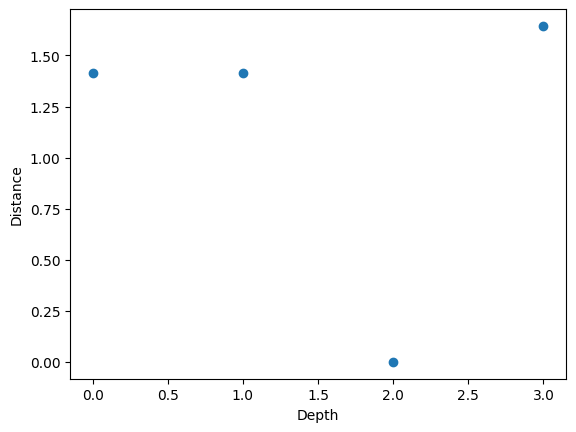

In [8]:
dist = []
# reference_state = result.data(0)[f"psi_{4}"].data
for i in range(4):
    sv = result.data(0)[f"psi_{i}"]
    dist.append(np.abs(sv.data-reference_state).sum())
plt.scatter(np.arange(4), dist)
plt.xlabel("Depth")
plt.ylabel("Distance")